In [4]:
import os
import shutil

# Get the current working directory (where the script is running)
base_path = os.getcwd()
# Go one level up from the base path
parent_path = os.path.dirname(os.path.dirname(base_path))
# Define paths for the 'data/GAE' folder and the new subfolders
fig_path = os.path.join(base_path , "figures")
gae_data_path = os.path.join(fig_path, "logistic regression")
# if os.path.exists(gae_data_path):
#     shutil.rmtree(gae_data_path)
#     print(f"Deleted folder: {gae_data_path}")
# else:
#     print(f"Folder does not exist: {gae_data_path}")
# Create 'data' directory if it doesn't exist
os.makedirs(fig_path, exist_ok=True)

# Create 'GAE' directory under 'data' if it doesn't exist
os.makedirs(gae_data_path, exist_ok=True)

In [5]:
import pandas as pd
import numpy as np
# Plot ROC curve
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, roc_curve, auc, roc_auc_score, 
                             mean_squared_error, f1_score, accuracy_score, classification_report)
from statsmodels.stats.outliers_influence import variance_inflation_factor
import joblib
import shap
from imblearn.over_sampling import SMOTE
from sklearn.metrics import precision_score, recall_score, roc_auc_score


data = pd.read_excel('data/curated dataset/curated_dataset_molecular_properties.xlsx')


X = data.drop(['SMILES', 'descriptors', 'frag_likeliness'], axis=1)
y = data['frag_likeliness']


X = X.select_dtypes(include=[np.number])


original_num_attributes = X.shape[1]


smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Function to remove highly correlated features
def remove_highly_correlated_features(X, threshold=0.75):
    corr_matrix = X.corr().abs()
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > threshold)]
    return X.drop(columns=to_drop), to_drop

# Remove highly correlated features
X, dropped_features_corr = remove_highly_correlated_features(X_resampled, threshold=0.75)

# Function to calculate VIF
def calculate_vif(X):
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif_data

# Step 2: Remove multicollinearity using VIF
vif_data = calculate_vif(X)
print("Initial VIF:")
print(vif_data)
# Remove features with VIF > 5
vif_threshold = 5
dropped_features_vif = []
while vif_data["VIF"].max() > vif_threshold:
    remove = vif_data.sort_values("VIF", ascending=False).iloc[0]
    X = X.drop(columns=[remove["Feature"]])
    dropped_features_vif.append(remove["Feature"])
    vif_data = calculate_vif(X)
    print(f"Removed {remove['Feature']} with VIF = {remove['VIF']:.2f}")

# Number of attributes removed
num_dropped_corr = len(dropped_features_corr)
num_dropped_vif = len(dropped_features_vif)
num_available_attributes = X.shape[1]

print(f"\nOriginal number of attributes: {original_num_attributes}")
print(f"Number of attributes removed due to high correlation (> 0.75): {num_dropped_corr}, Names: {dropped_features_corr}")
print(f"Number of attributes removed due to VIF (> {vif_threshold}): {num_dropped_vif}, Names: {dropped_features_vif}")
print(f"Number of attributes available for building the equation: {num_available_attributes}")


Initial VIF:
                             Feature       VIF
0                                QED  0.098205
1                               logP  0.999796
2                   Molecular Weight  0.299668
3                    Rotatable Bonds  0.523401
4                         Ring Count  0.873277
5                      Formal Charge  0.999686
6   Fraction of Sp2 Hybridized Atoms  0.263798
7           Number of Aromatic Rings  0.791741
8                                Ipc  1.237964
9                             Kappa1  0.825312
10                            Kappa3  0.998421
11                         PEOE_VSA2  0.726521
12                         PEOE_VSA3  0.817641
13                          SMR_VSA2  0.991069
14                          SMR_VSA3  0.897198
15                        SlogP_VSA3  0.546333
16                       FCFP4 Count  0.214786
17                   Num Spiro Atoms  0.991984
18        Aliphatic Heteroatom Count  0.909384
19          Average Molecular Weight  0.085286


Accuracy: 0.9370 ± 0.0034
Precision: 0.9222 ± 0.0071
Recall: 0.9538 ± 0.0020
F1 Score: 0.9377 ± 0.0036
AUC: 0.9769 ± 0.0034


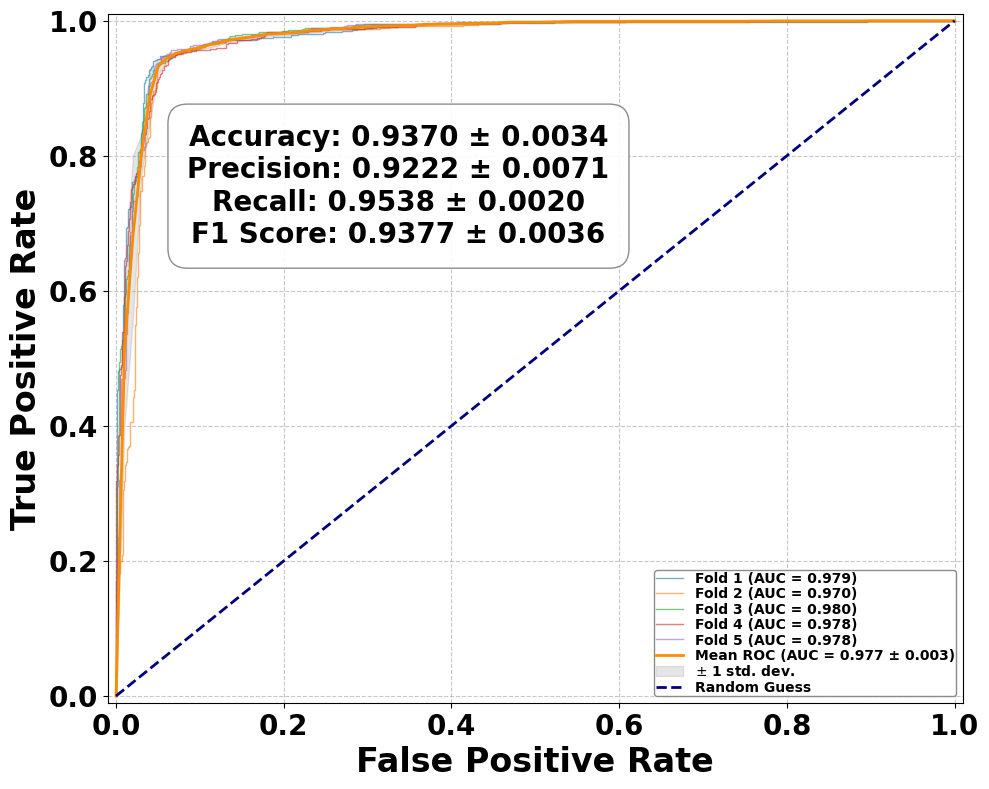


Test Set Metrics:
Accuracy: 0.9394
Precision: 0.9319
Recall: 0.9509
F1 Score: 0.9413
AUC: 0.9781


In [6]:
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc, precision_score, recall_score, f1_score, accuracy_score
import numpy as np
import matplotlib.pyplot as plt

# First, split data into training and test sets (keeping test set aside)
X_train, X_test, y_train, y_test = train_test_split(X, y_resampled, test_size=0.2, random_state=42)

# Create a StandardScaler
scaler = StandardScaler()

# Scale the training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create the model
model = LogisticRegression(random_state=42)

# Set up 5-fold cross validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Lists to store metrics for each fold
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)


plt.figure(figsize=(10, 8))

# Perform cross-validation manually to get ROC curves for each fold
fold = 1
for train_idx, val_idx in kf.split(X_train_scaled):
    # Split data for this fold
    X_fold_train, X_fold_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    # Train model on this fold
    fold_model = LogisticRegression(random_state=42)
    fold_model.fit(X_fold_train, y_fold_train)
    threshold1=0.5276
   
    y_pred = (fold_model.predict_proba(X_fold_val)[:, 1] >= threshold1).astype(int)

    y_pred_proba = fold_model.predict_proba(X_fold_val)[:, 1]
    
    # Calculate metrics for this fold
    accuracy_scores.append(accuracy_score(y_fold_val, y_pred))
    precision_scores.append(precision_score(y_fold_val, y_pred))
    recall_scores.append(recall_score(y_fold_val, y_pred))
    f1_scores.append(f1_score(y_fold_val, y_pred))
    
    # Calculate ROC curve and AUC for this fold
    fpr, tpr, _ = roc_curve(y_fold_val, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    
    # Interpolate TPR values for common FPR values
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    
    # Plot ROC curve for this fold
    plt.plot(fpr, tpr, lw=1, alpha=0.6, label=f'Fold {fold} (AUC = {roc_auc:.3f})')
    fold += 1


mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = np.mean(aucs)
std_auc = np.std(aucs)
plt.plot(mean_fpr, mean_tpr, color='darkorange', lw=2, 
         label=f'Mean ROC (AUC = {mean_auc:.3f} \u00B1 {std_auc:.3f})')

# Calculate and plot the standard deviation around the mean ROC curve
std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=0.2,
                 label=r'$\pm$ 1 std. dev.')



plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
# Format the ROC plot
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('False Positive Rate', fontsize=24, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=24, fontweight='bold')

plt.legend( fontsize=60, prop={'weight': 'bold'}, 
           framealpha=0.9, edgecolor='gray', fancybox=True, frameon=True, 
           borderpad=0.1, labelspacing=0.1)
plt.xticks(fontsize=20, fontweight='bold')  
plt.yticks(fontsize=20, fontweight='bold') 

plt.grid(True, linestyle='--', alpha=0.7)

# Calculate and format metrics as mean ± std
mean_accuracy = np.mean(accuracy_scores)
std_accuracy = np.std(accuracy_scores)

mean_precision = np.mean(precision_scores)
std_precision = np.std(precision_scores)

mean_recall = np.mean(recall_scores)
std_recall = np.std(recall_scores)

mean_f1 = np.mean(f1_scores)
std_f1 = np.std(f1_scores)

# Print metrics
print(f"Accuracy: {mean_accuracy:.4f} \u00B1 {std_accuracy:.4f}")
print(f"Precision: {mean_precision:.4f} \u00B1 {std_precision:.4f}")
print(f"Recall: {mean_recall:.4f} \u00B1 {std_recall:.4f}")
print(f"F1 Score: {mean_f1:.4f} \u00B1 {std_f1:.4f}")
print(f"AUC: {mean_auc:.4f} \u00B1 {std_auc:.4f}")

# Add text box with metrics to the plot
metrics_text = (f"Accuracy: {mean_accuracy:.4f} \u00B1 {std_accuracy:.4f}\n"
                f"Precision: {mean_precision:.4f} \u00B1 {std_precision:.4f}\n"
                f"Recall: {mean_recall:.4f} \u00B1 {std_recall:.4f}\n"
                f"F1 Score: {mean_f1:.4f} \u00B1 {std_f1:.4f}")

# plt.annotate(metrics_text, xy=(0.5, 0.1), xycoords='axes fraction',
#              bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="gray", alpha=0.8),
#              verticalalignment='center', horizontalalignment='center', fontweight='bold')
# plt.annotate(metrics_text, xy=(0.5, 0.1), xycoords='axes fraction',
#              bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="gray", alpha=0.8),
#              verticalalignment='center', horizontalalignment='center',
#              fontsize=15, fontweight='bold')
plt.annotate(metrics_text, xy=(0.34, 0.75), xycoords='axes fraction',  # Repositioned
             bbox=dict(boxstyle="round,pad=0.7", fc="white", ec="gray", alpha=0.9),  # Bigger padding
             verticalalignment='center', horizontalalignment='center',
             fontsize=20, fontweight='bold')
plt.tight_layout()
dpi_values = [300, 600, 1200]  # DPI levels

output_folder = 'figures/logistic regression/5 fold results/' 
os.makedirs(output_folder, exist_ok=True) 
for dpi in dpi_values:
    plt.savefig(f"{output_folder}5_fold_cv_logisticregression_{dpi}dpi.png", dpi=dpi, bbox_inches='tight')
plt.show()

# Now train the final model on the entire training set and evaluate on test set
final_model = LogisticRegression(random_state=42)
final_model.fit(X_train_scaled, y_train)

# Calculate metrics on test set
y_test_pred = (final_model.predict_proba(X_test_scaled)[:, 1] >= threshold1).astype(int)

y_test_pred_proba = final_model.predict_proba(X_test_scaled)[:, 1]

test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_fpr, test_tpr, _ = roc_curve(y_test, y_test_pred_proba)
test_auc = auc(test_fpr, test_tpr)

print("\nTest Set Metrics:")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")
print(f"F1 Score: {test_f1:.4f}")
print(f"AUC: {test_auc:.4f}")